In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import datetime

import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision.transforms import v2
from torchvision.io import decode_image
from torchvision.models import resnet50

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
# EDIT DIRECTORY VARIABLES AS NEEDED
# --- Main Directory: contains all folders/files
root = "S:/CheXpert/"
# --- This is the original root listed on the csv file paths
old_root = "CheXpert-v1.0/train/"
old_test_root = "test/"

# --- Input directory variables
source_train_root1 = f"{root}raw_data/CheXpert-v1.0 batch 2 (train 1)/"
source_train_root2 = f"{root}raw_data/CheXpert-v1.0 batch 3 (train 2)/"
source_train_root3 = f"{root}raw_data/CheXpert-v1.0 batch 4 (train 3)/"
source_valid_rad_root = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid/"
source_test_rad_root = f"{root}raw_data/test/"

# --- Output directory variables
train_valid_root = f"{root}train_valid/"
test_root = f"{root}test/"
valid_rad_root = f"{root}valid_rad/" 
test_rad_root = f"{root}test_rad/"

# --- Filepaths for dfs
train_df_filepath = f"{root}train_df.csv"
train_df_full_filepath = f"{root}train_df_full.csv"
#
valid_df_filepath = f"{root}valid_df.csv"
test_df_filepath = f"{root}test_df.csv"
#
valid_rad_df_filepath = f"{root}valid_rad_df.csv"
test_rad_df_filepath = f"{root}test_rad_df.csv"

# --- Image sizes
dims = [224, 384, 512]

In [3]:
### Results metadata
model_n_samples = 120000
n_class_values = 3

# Results data frames --> Make sure these paths are correct
resnet_base224_path = f"results/ResNet50_BASE224_120000samples_test_withPredictionsAndConfidences.csv"
resnet_base224_enhanced_path = f"results/ResNet50_BASE224_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base224_path = f"results/DenseNet121_BASE224_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base224_enhanced_path = f"results/DenseNet121_BASE224_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
#
resnet_base384_path = f"results/ResNet50_BASE384_120000samples_test_withPredictionsAndConfidences.csv"
resnet_base384_enhanced_path = f"results/ResNet50_BASE384_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base384_path = f"results/DenseNet121_BASE384_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base384_enhanced_path = f"results/DenseNet121_BASE384_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
#
resnet_base512_path = f"results/ResNet50_BASE512_120000samples_test_withPredictionsAndConfidences.csv"
resnet_base512_enhanced_path = f"results/ResNet50_BASE512_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base512_path = f"results/DenseNet121_BASE512_120000samples_test_withPredictionsAndConfidences.csv"
densenet_base512_enhanced_path = f"results/DenseNet121_BASE512_ENHANCED_120000samples_test_withPredictionsAndConfidences.csv"
###
results_dfs = {
    "resnet_base224":pd.read_csv(resnet_base224_path, index_col=0),
    "resnet_base224_enhanced":pd.read_csv(resnet_base224_enhanced_path, index_col=0),
    "densenet_base224":pd.read_csv(densenet_base224_path, index_col=0),
    "densenet_base224_enhanced":pd.read_csv(densenet_base224_enhanced_path, index_col=0),
    #
    "resnet_base384":pd.read_csv(resnet_base384_path, index_col=0),
    "resnet_base384_enhanced":pd.read_csv(resnet_base384_enhanced_path, index_col=0),
    "densenet_base384":pd.read_csv(densenet_base384_path, index_col=0),
    "densenet_base384_enhanced":pd.read_csv(densenet_base384_enhanced_path, index_col=0),
    #
    "resnet_base512":pd.read_csv(resnet_base512_path, index_col=0),
    "resnet_base512_enhanced":pd.read_csv(resnet_base512_enhanced_path, index_col=0),
    "densenet_base512":pd.read_csv(densenet_base512_path, index_col=0),
    "densenet_base512_enhanced":pd.read_csv(densenet_base512_enhanced_path, index_col=0),
}
results_dfs_names, results_dfs_data = [], []
for name,data in results_dfs.items():
    results_dfs_names.append(name)
    results_dfs_data.append(data)

# Class metadata columns
class_cols = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
           'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
           'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
           'Support Devices', 'No Finding']
pred_cols = [col + "_pred" for col in class_cols]
confidence_cols = [col + "_confidence" for col in class_cols]
byModel_palette = dict(zip(results_dfs_names, sns.color_palette("tab20", n_colors=len(class_cols))))
byClass_palette = dict(zip(class_cols, sns.color_palette("tab20", n_colors=len(class_cols))))

metrics_kwargs = dict(
    class_cols = class_cols,
    pred_cols = pred_cols,
    confidence_cols = confidence_cols,
    n_class_values = n_class_values
)

In [4]:
def get_accuracy(predictions, actual):
    """Given list-like predictions and corresponding list-like actual, return the accuracy"""
    return np.mean(np.array(predictions)==np.array(actual))

In [5]:
def get_metrics_byClassAndValue(df, pred_col, class_col, n_class_values, **kwargs):
    """
    Given:
        df: The data frame of results from the model
    Return:
        avgstats_byClass: Average metrics given at the class level
            ex: Average precision for Pneumonia
        stats_byClass_byValue_i: Metrics given at the class value level
            ex: Precision for Pneumonia when actual = 1
    * Average metrics use nanmean to ignore any NaN values
    """
    statsByClass = {}
    avgstats_byClass = {}
    stats = ["Value", "TP", "FP", "FN", "TN",
             "TPR", "FPR", "FNR", "TNR", "Precision", "Recall", "BER", "F1 Score"]
    # Stats
    avg_class_stats = np.zeros((len(stats), n_class_values))
    for i in range(n_class_values):
        val_predict_pos = df[pred_col].map(lambda x: 1 if x==i else 0).to_numpy()
        val_actual_pos = df[class_col].map(lambda x: 1 if x==i else 0).to_numpy()
        # 
        TP = np.sum((val_predict_pos==1) & (val_actual_pos==1))
        FN = np.sum((val_predict_pos==0) & (val_actual_pos==1))
        FP = np.sum((val_predict_pos==1) & (val_actual_pos==0))
        TN = np.sum((val_predict_pos==0) & (val_actual_pos==0))
        #
        TPR = TP / (TP + FN)  ### Sensitivity
        TNR = TN / (TN + FP)  ### Specificity
        FPR = FP / (TN + FP)
        FNR = FN / (FN + TP)
        #
        BER = (1/2) * (FPR + FNR)
        #
        prec = (TP + 1) / (TP + FP + 1)
        recall = (TP + 1) / (TP + FN + 1)
        f1_score = 2 * ((prec * recall) / (prec + recall))
        statsByClass[i] = {"Value":i,
                           "TP":TP, "FP":FP, "FN":FN, "TN":TN,
                           "TPR":TPR, "FPR":FPR, "FNR":FNR, "TNR":TNR, 
                           "Precision":prec, "Recall":recall,
                           "BER":BER, "F1 Score":f1_score}
        avg_class_stats[:,i] = [i, TP, FP, FN, TN, TPR, FPR, FNR, TNR, prec, recall, BER, f1_score]

    # Aggregate stats across classes
    for i,stat in enumerate(stats):
        avgstats_byClass["Avg Class " + stat] = np.nanmean(avg_class_stats[i,:])
    stats_byClass_byValue_i = pd.DataFrame.from_dict(statsByClass).T
    stats_byClass_byValue_i["Class"] = class_col
        
    return avgstats_byClass, stats_byClass_byValue_i, stats

In [6]:
def get_metrics_byClass(df, class_cols, pred_cols, confidence_cols, n_class_values=3, **kwargs):
    """
    Given:
        df: The data frame of results from the model
    Return:
        output_stats: A dictionary containing:
            stats_byClass_byValue: Metrics given at the class value level
                ex: Precision for Pneumonia when actual = 1
            avgstats_byClass: Average metrics given at the class level
                ex: Average precision for Pneumonia
            avgStats_byValue: Average metrics given at the value level
                ex: Average precision for all actual positive instances
        stats_byClass
    * Average metrics use nanmean to ignore any NaN values
    """
    output_stats = {}

    predictions = df[pred_cols].to_numpy()
    actual = df[class_cols].to_numpy()

    # Get accuracy
    output_stats["Overall Accuracy"] = get_accuracy(predictions, actual)

    # Get accuracy by class, as well as precision and recall at the different levels
    acc_byClass = {}
    avgstats_byClass = {}
    stats_byClass = {}
    for i,(class_col,pred_col) in enumerate(zip(class_cols, pred_cols)):
        col_predictions = df[pred_col].to_numpy()
        col_actual = df[class_col].to_numpy()
        acc_byClass[class_col] = get_accuracy(col_predictions, col_actual)
        #
        avgstats_byClass_i, stats_byClass_byValue_i, stats = get_metrics_byClassAndValue(df, 
                                                                                         pred_col, 
                                                                                         class_col, 
                                                                                         n_class_values,
                                                                                        **kwargs)
        stats_byClass[class_col] = stats_byClass_byValue_i
        avgstats_byClass[class_col] = avgstats_byClass_i

        if i==0:
            stats_byClass_byValue = stats_byClass_byValue_i.copy()
        else:
            stats_byClass_byValue = pd.concat([stats_byClass_byValue, stats_byClass_byValue_i], axis=0)

    avgstats_byValue = np.zeros((n_class_values, len(stats), len(class_cols)))
    # Aggregate stats_byClass to get avgstats_byValue
    for i,(key) in enumerate(stats_byClass.keys() ):
        avgstats_byValue[:,:,i] = stats_byClass[key].iloc[:,:-1]

    output_stats["Stats by Class by Value"] = stats_byClass_byValue.reset_index(drop=True)
    output_stats["Avg Stats by Class"] = pd.DataFrame(avgstats_byClass)
    output_stats["Avg Stats by Value"] = pd.DataFrame(avgstats_byValue.mean(axis=2), columns=["Avg Value " + stat for stat in stats]).T

    return output_stats, stats_byClass

In [7]:
def get_metrics(dfs, output_cols, class_cols, pred_cols, confidence_cols, n_class_values=3, **kwargs):
    """
    Get average metrics for input data frames
    Given:
        dfs: A list of data frames where the columns are the metrics, and the rows are test set instances
        output_cols: A list of output column names representing the corresponding df names
    Return:
        avgModelStats_byClass: a data frame where each row contains stats for each model, aggregated by class
        avgModelStats_byValue: a data frame where each row contains stats for each model, aggregated by value
        stats_byClass_byValue: a dictionary of dictionaries, one per model containing the unaggregated metrics
            Overall Accuracy: The averaged accuracy across all class values for the model
            Stats by Class by Value: A data frame containing the stats for each class value
            Avg Stats by Class: A data frame containing the stats aggregated by class
            Avg Stats by Value: A data frame containing the stats aggregated by value
    * Average metrics use nanmean to ignore any NaN values
    """
    if len(dfs) != len(output_cols):
        print("len(dfs) must match len(output_cols)")
        return None
    else:
        avgModelStats_byClass, avgModelStats_byValue = {}, {}
        stats_byClass_byValue = {}
        for df,output_col in zip(dfs, output_cols):
            stats_dict, stats_dict_byClass = get_metrics_byClass(df, 
                                                                 class_cols, 
                                                                 pred_cols, 
                                                                 confidence_cols,
                                                                 n_class_values,
                                                                 **kwargs)
            df1 = stats_dict["Avg Stats by Class"].loc[["Avg Class Precision", 
                                                        "Avg Class TPR",
                                                        "Avg Class Recall", 
                                                        "Avg Class TNR",
                                                        "Avg Class F1 Score",
                                                        "Avg Class BER"],:].mean(axis=1)
            df2 = stats_dict["Avg Stats by Value"].loc[["Avg Value Precision", 
                                                        "Avg Value TPR",
                                                        "Avg Value Recall", 
                                                        "Avg Value TNR",
                                                        "Avg Value F1 Score",
                                                        "Avg Value BER"],:].mean(axis=1)
            avgModelStats_byClass[output_col] = df1
            avgModelStats_byValue[output_col] = df2
            stats_byClass_byValue[output_col] = stats_dict
            
        avgModelStats_byClass = pd.DataFrame.from_dict(avgModelStats_byClass).T
        avgModelStats_byValue = pd.DataFrame.from_dict(avgModelStats_byValue).T
        return (avgModelStats_byClass, avgModelStats_byValue, stats_byClass_byValue)


In [8]:
def plot_avg_metrics(df, palette=None, n_plots_x=None, n_plots_y=None, grid=None, figsize=None):
    if n_plots_x is None: n_plots_x = int(len(df.columns)/2)
    if n_plots_y is None: n_plots_y = 2
    if figsize is None: figsize=(10, n_plots_y*5)
    fig, axes = plt.subplots(n_plots_x, n_plots_y, figsize=figsize)
    for i,(ax,col) in enumerate(zip(axes.flatten(), df.columns)):
        plot_df = df[[col]].sort_values(by=col, ascending=False).reset_index().rename(columns={"index":"Row"})
        if palette:
            sns.barplot(data=plot_df, y="Row", x=col, hue="Row", palette=palette, ax=ax, order=plot_df["Row"], width=0.75, gap=0.025)
        else:
            sns.barplot(data=plot_df, y="Row", x=col, hue="Row", ax=ax, order=plot_df["Row"], width=0.75, gap=0.025)
        ax.set(title=col, xlim=(0,1), ylabel="", xlabel="")
        if grid:
            ax.grid(axis="x")
    return fig,axes

In [9]:
def plot_multiple_avg_metrics(df, metrics_cols, n_plots_x=None, n_plots_y=None, grid=None, figsize=(5,5)):
    if n_plots_x is None: n_plots_x = len(df.columns)
    if n_plots_y is None: n_plots_y = 1
    fig, axes = plt.subplots(n_plots_x, n_plots_y, figsize=figsize)
    for i,(ax,metric_col) in enumerate(zip(axes.flatten(), metrics_cols)):
        plot_df = df.sort_values(by=metric_col, ascending=False)
        sns.barplot(data=plot_df, y="Condition", x=metric_col, hue="Image Type", ax=ax, orient="h")
        ax.set(title=metric_col, xlim=(0,1), ylabel="", xlabel="")
        if grid:
            ax.grid(axis="x")
    plt.tight_layout()
    return fig,axes

In [10]:
### Get stats
avgModelStats_byClass, avgModelStats_byValue, stats_byClass_byValue = get_metrics(results_dfs_data, 
                                                                                  results_dfs_names, 
                                                                                  **metrics_kwargs)

C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:27: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / (TP + FN)  ### Sensitivity
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:30: RuntimeWarning: invalid value encountered in scalar divide
  FNR = FN / (FN + TP)
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:27: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / (TP + FN)  ### Sensitivity
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:30: RuntimeWarning: invalid value encountered in scalar divide
  FNR = FN / (FN + TP)
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:27: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / (TP + FN)  ### Sensitivity
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:30: RuntimeWarning: invalid value encountered in scalar divide
  FNR = FN / (FN + TP)
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632

,Avg Class Precision,Avg Class TPR,Avg Class Recall,Avg Class TNR,Avg Class F1 Score,Avg Class BER
resnet_base224,0.401245,0.403812,0.416156,0.714533,0.357329,0.445061
resnet_base224_enhanced,0.397095,0.384003,0.398022,0.701075,0.357521,0.462500
densenet_base224,0.405397,0.416790,0.428075,0.725158,0.380987,0.432710
densenet_base224_enhanced,0.402463,0.415451,0.427288,0.720682,0.371809,0.435908
resnet_base384,0.407683,0.407040,0.418581,0.716086,0.369474,0.442250
resnet_base384_enhanced,0.395872,0.398183,0.410798,0.710879,0.354695,0.449821
densenet_base384,0.420830,0.426249,0.437294,0.730010,0.387673,0.425448
densenet_base384_enhanced,0.433531,0.413074,0.424729,0.719232,0.379917,0.437718
resnet_base512,0.411196,0.415532,0.427050,0.723188,0.374622,0.434442
resnet_base512_enhanced,0.406573,0.407087,0.419800,0.717699,0.364481,0.442008


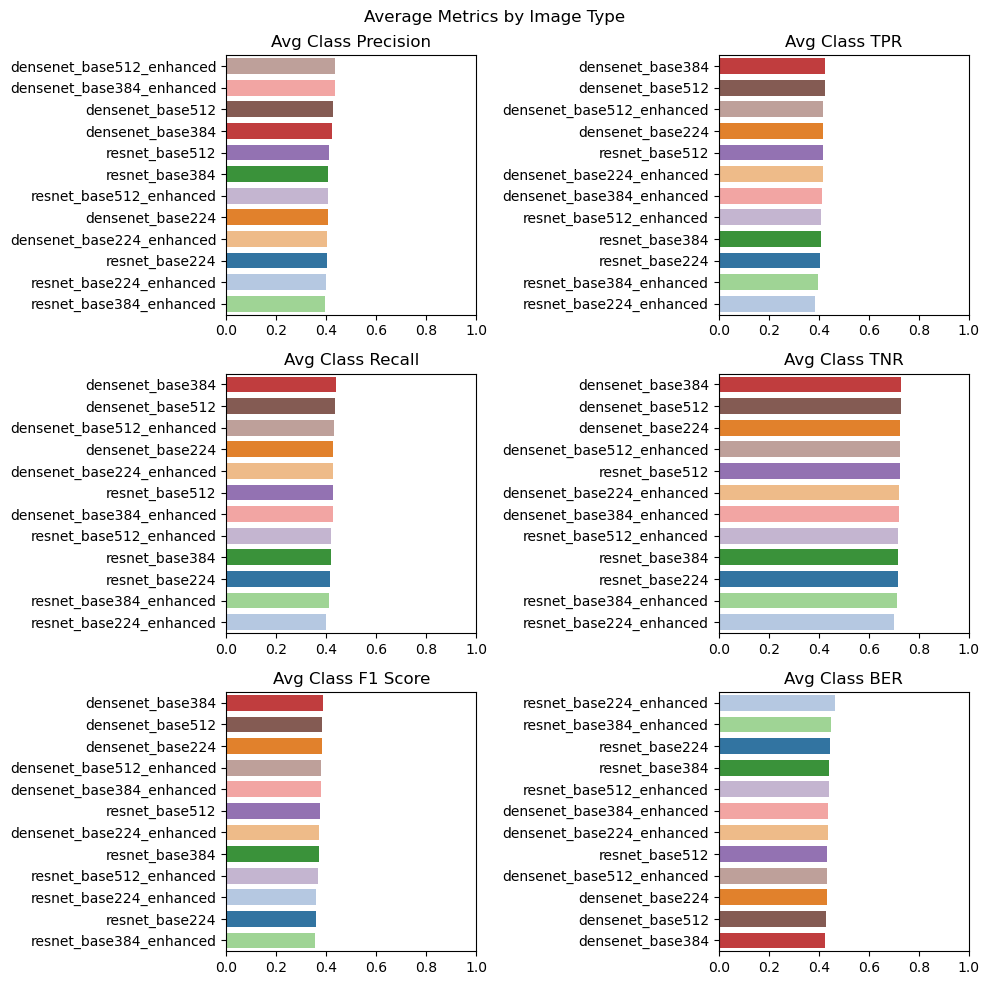

In [11]:
### Visualize
plot_fig, plot_axes = plot_avg_metrics(avgModelStats_byClass, byModel_palette)
plt.suptitle("Average Metrics by Image Type")
plt.tight_layout()
#
avgModelStats_byClass

In [12]:
print("Breakdown of contents for stats_byClass_byValue")
for key,values in stats_byClass_byValue.items():
    print(f"Key1: {key}")
    for key2,values2 in values.items():
        print(f"\tKey2: {key2}")

Breakdown of contents for stats_byClass_byValue
Key1: resnet_base224
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: resnet_base224_enhanced
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: densenet_base224
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: densenet_base224_enhanced
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: resnet_base384
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: resnet_base384_enhanced
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: densenet_base384
	Key2: Overall Accuracy
	Key2: Stats by Class by Value
	Key2: Avg Stats by Class
	Key2: Avg Stats by Value
Key1: densenet_base384_

In [13]:
### Example data
stats_byClass_byValue["densenet_base224_enhanced"]["Stats by Class by Value"]

,Value,TP,FP,FN,TN,TPR,FPR,FNR,TNR,Precision,Recall,BER,F1 Score,Class
0,0.0,25180.0,2782.0,10104.0,1305.0,0.713638,0.680695,0.286362,0.319305,0.900511,0.713646,0.483528,0.796262,Enlarged Cardiomediastinum
1,1.0,552.0,10797.0,834.0,27188.0,0.398268,0.284244,0.601732,0.715756,0.048722,0.398702,0.442988,0.086834,Enlarged Cardiomediastinum
2,2.0,4.0,56.0,2697.0,36614.0,0.001481,0.001527,0.998519,0.998473,0.081967,0.001850,0.500023,0.003619,Enlarged Cardiomediastinum
3,0.0,21142.0,2562.0,12792.0,2875.0,0.623033,0.471216,0.376967,0.528784,0.891922,0.623044,0.424091,0.733622,Cardiomegaly
4,1.0,2364.0,11159.0,2396.0,23452.0,0.496639,0.322412,0.503361,0.677588,0.174874,0.496744,0.412887,0.258682,Cardiomegaly
5,2.0,34.0,2110.0,643.0,36584.0,0.050222,0.054530,0.949778,0.945470,0.016317,0.051622,0.502154,0.024796,Cardiomegaly
6,0.0,9972.0,5580.0,10380.0,13439.0,0.489976,0.293391,0.510024,0.706609,0.641227,0.490001,0.401707,0.555506,Lung Opacity
7,1.0,12867.0,9670.0,6111.0,10723.0,0.677996,0.474182,0.322004,0.525818,0.570947,0.678013,0.398093,0.619891,Lung Opacity
8,2.0,1.0,1281.0,40.0,38049.0,0.024390,0.032571,0.975610,0.967429,0.001559,0.047619,0.504090,0.003019,Lung Opacity
9,0.0,30376.0,1116.0,7275.0,604.0,0.806778,0.648837,0.193222,0.351163,0.964564,0.806783,0.421030,0.878646,Lung Lesion


In [19]:
### Example data
stats_byClass_byValue["densenet_base224_enhanced"]["Avg Stats by Value"]

,0,1,2
Avg Value Value,0.000000,1.000000,2.000000
Avg Value TP,21333.857143,3807.285714,140.357143
Avg Value FP,3521.928571,8905.428571,1662.142857
Avg Value FN,9810.714286,2699.785714,1579.000000
Avg Value TN,4704.500000,23958.500000,35989.500000
Avg Value TPR,0.672650,0.457996,NaN
Avg Value FPR,0.507446,0.286062,0.044447
Avg Value FNR,0.327350,0.542004,NaN
Avg Value TNR,0.492554,0.713938,0.955553
Avg Value Precision,0.845246,0.223512,0.138632


In [14]:
for i,name in enumerate(results_dfs_names):
    print(f"{i}: {name}")

0: resnet_base224
1: resnet_base224_enhanced
2: densenet_base224
3: densenet_base224_enhanced
4: resnet_base384
5: resnet_base384_enhanced
6: densenet_base384
7: densenet_base384_enhanced
8: resnet_base512
9: resnet_base512_enhanced
10: densenet_base512
11: densenet_base512_enhanced


C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:27: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / (TP + FN)  ### Sensitivity
C:\Users\johnt\AppData\Local\Temp\ipykernel_38632\1765699657.py:30: RuntimeWarning: invalid value encountered in scalar divide
  FNR = FN / (FN + TP)


,Avg Class Precision,Avg Class Recall,Avg Class F1 Score,Avg Class TPR,Avg Class TNR,Avg Class BER
Enlarged Cardiomediastinum,0.351797,0.370329,0.289412,0.370065,0.678759,0.475588
Cardiomegaly,0.378872,0.394025,0.383133,0.393498,0.720468,0.443017
Lung Opacity,0.450008,0.412428,0.412003,0.404478,0.737720,0.428901
Lung Lesion,0.366281,0.400154,0.360117,0.398632,0.717593,0.441888
Edema,0.448807,0.472621,0.448897,0.472503,0.763383,0.382057
Consolidation,0.374947,0.415374,0.287833,0.415260,0.710124,0.437308
Pneumonia,0.384498,0.392540,0.376101,0.392020,0.709164,0.449408
Atelectasis,0.389971,0.362522,0.346265,0.362435,0.685648,0.475959
Pneumothorax,0.357168,0.393002,0.167266,0.392330,0.713959,0.446855
Pleural Effusion,0.435159,0.438877,0.431237,0.438607,0.759696,0.400849


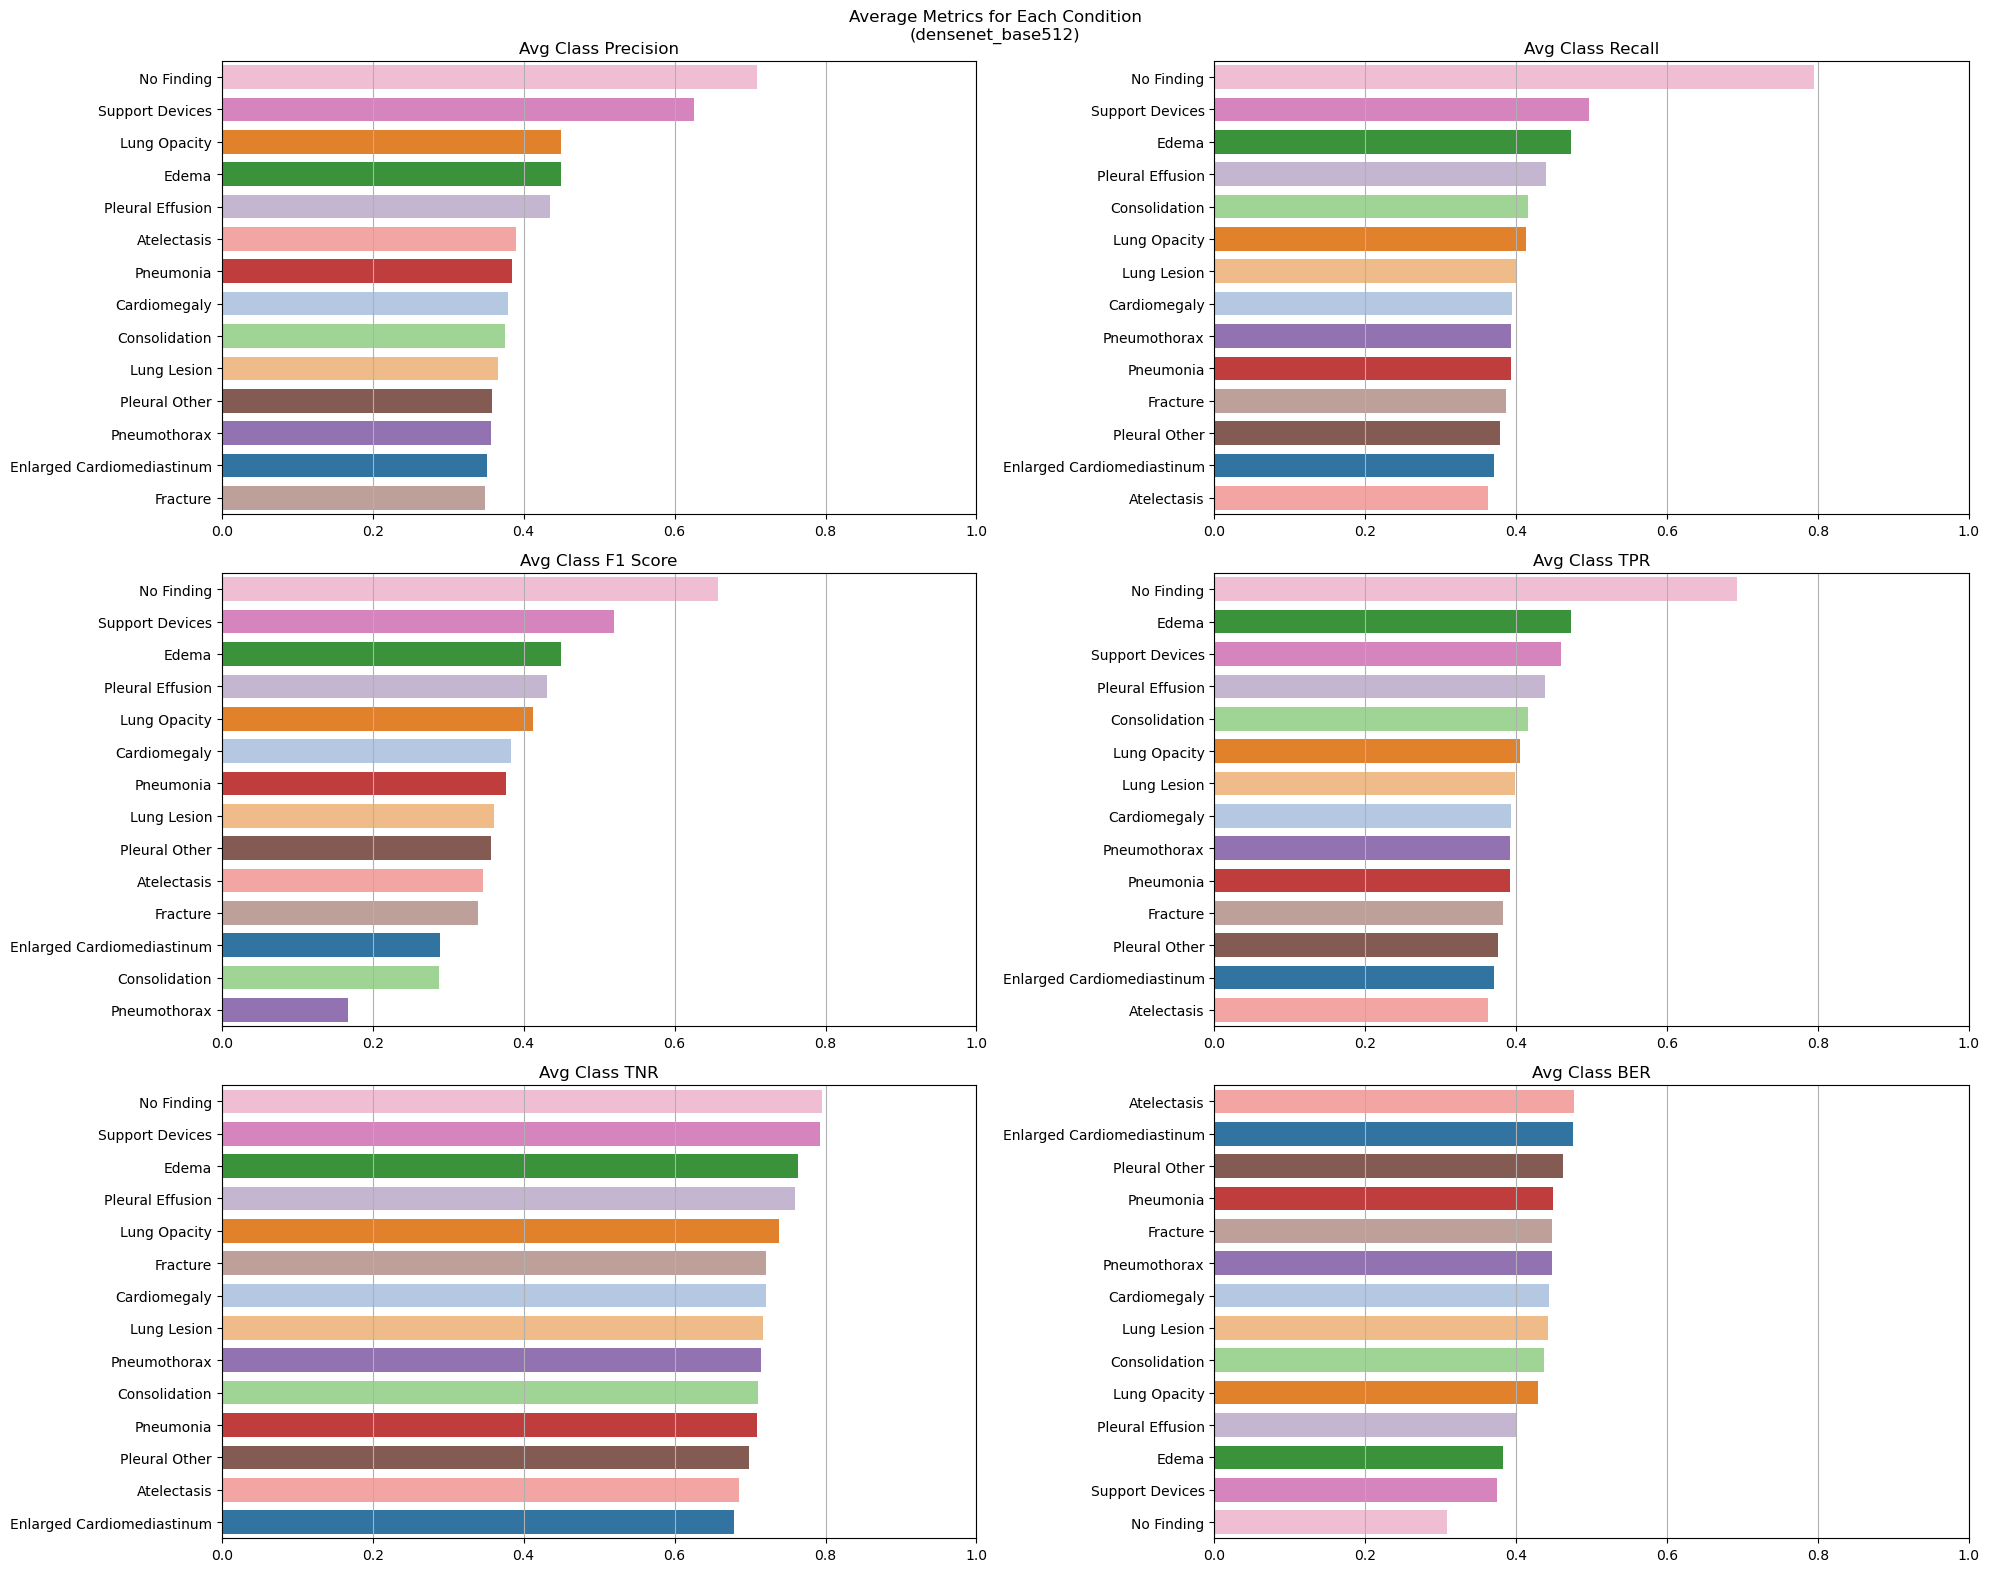

In [15]:
### View stats by training image type
name_ind = 10


output_col = results_dfs_names[name_ind]
input_df = results_dfs_data[name_ind]
#
n_plots_x = 3
n_plots_y = 2
figsize = (20,16)
#
stats_dict, stats_dict_byClass = get_metrics_byClass(input_df,
                                                     figsize=figsize,
                                                     **metrics_kwargs)
avg_metrics_byClass = stats_dict["Avg Stats by Class"].loc[["Avg Class Precision", 
                                                            "Avg Class Recall", 
                                                            "Avg Class F1 Score",
                                                            "Avg Class TPR", 
                                                            "Avg Class TNR", 
                                                            "Avg Class BER"],:].T
color_map = {}
plot_fig, plot_axes = plot_avg_metrics(avg_metrics_byClass, byClass_palette, n_plots_x, n_plots_y, figsize=figsize, grid=True)
plot_fig.suptitle(f"Average Metrics for Each Condition\n({output_col})")
plot_fig.tight_layout()
avg_metrics_byClass

In [16]:
metrics_cols = ["Avg Class Precision", 
               "Avg Class TPR",
               "Avg Class Recall", 
               "Avg Class TNR",
               "Avg Class F1 Score",
               "Avg Class BER"]